# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download the Viral Shorts Reels Performance Dataset](https://www.kaggle.com/datasets/prince7489/viral-shorts-and-reels-performance-analytics-dataset/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

/kaggle/input/datasets/rohitgrewal/loan-approval-dataset/loan_approval_dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('loan_approval_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## last Five row

In [4]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


## Shape of our dataset

In [5]:
df.shape

(4269, 13)

## List out all columns

In [6]:
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


## Check Null Value

In [9]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

## Check Dupicate Value**

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

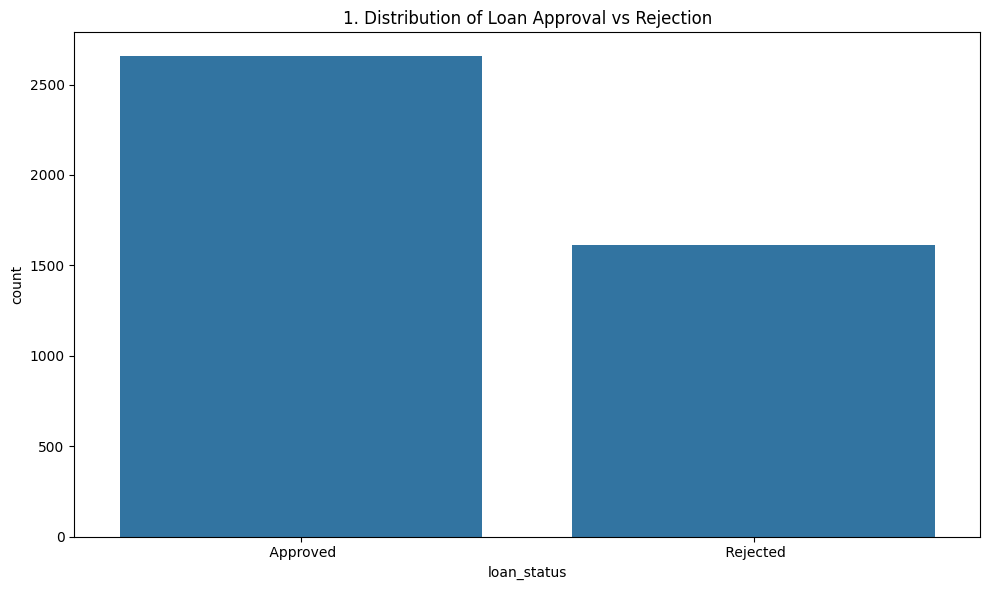

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='loan_status', data=df)
plt.title(f'{plot_no}. Distribution of Loan Approval vs Rejection')
show_fig()
plot_no += 1

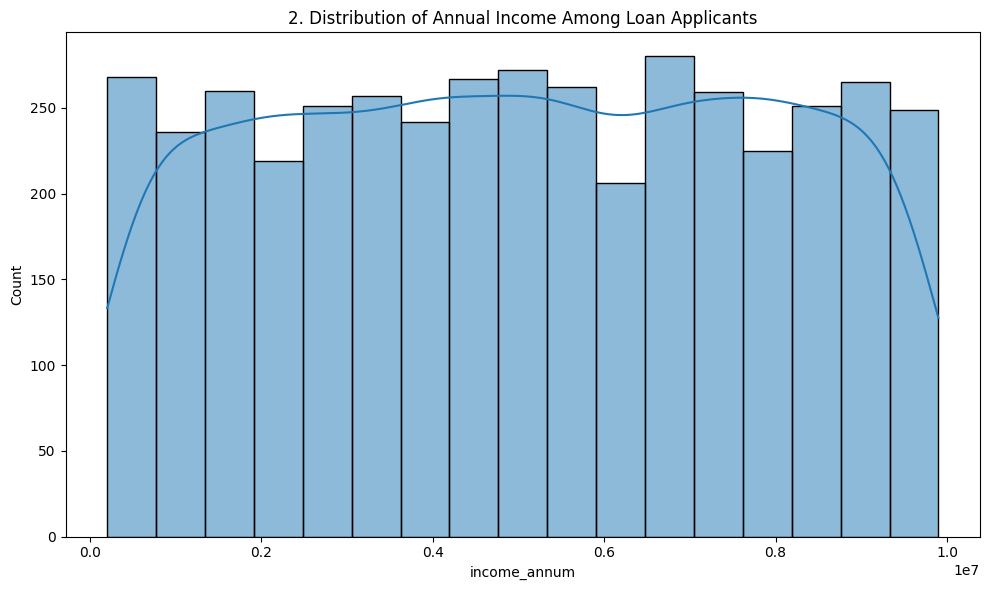

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['income_annum'], kde=True)
plt.title(f'{plot_no}. Distribution of Annual Income Among Loan Applicants')
show_fig()
plot_no += 1

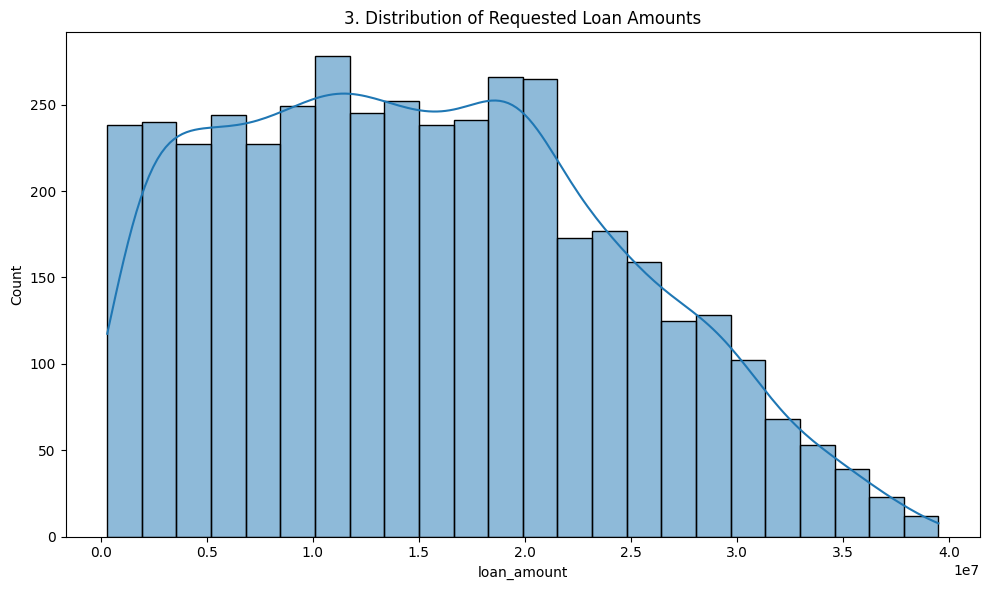

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['loan_amount'], kde=True)
plt.title(f'{plot_no}. Distribution of Requested Loan Amounts')
show_fig()
plot_no += 1

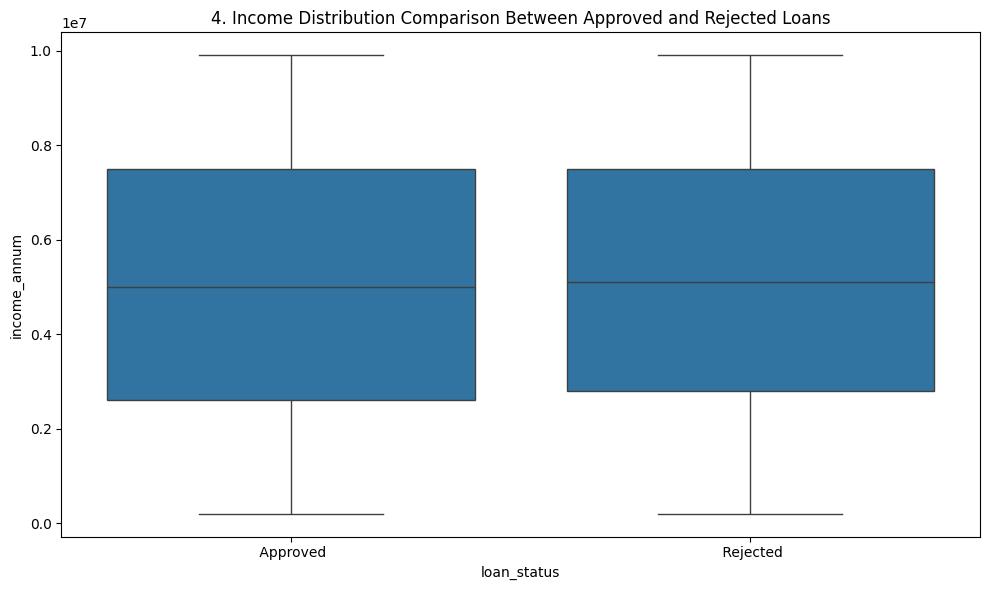

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='loan_status', y='income_annum', data=df)
plt.title(f'{plot_no}. Income Distribution Comparison Between Approved and Rejected Loans')
show_fig()
plot_no += 1

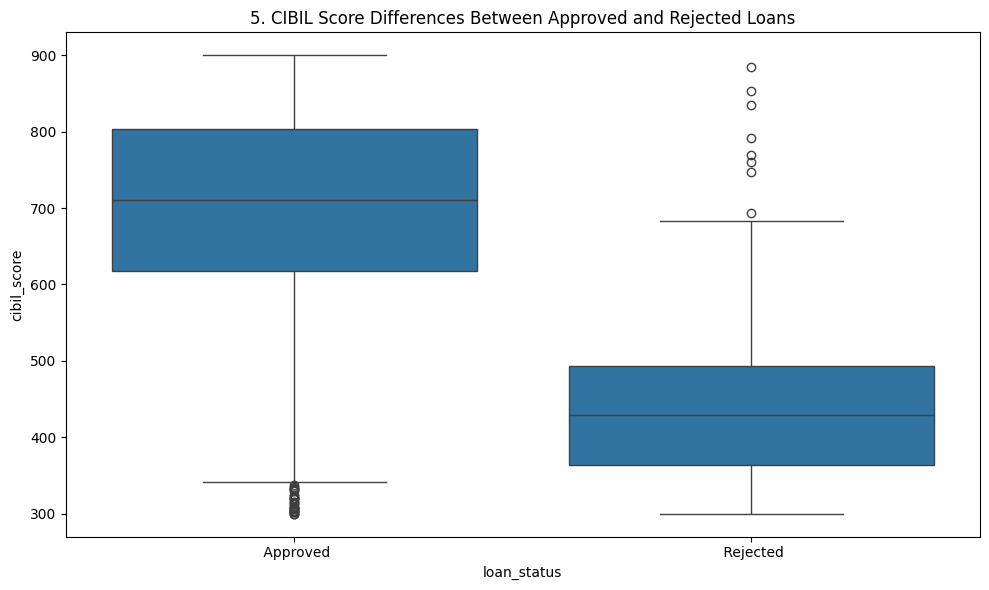

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.title(f'{plot_no}. CIBIL Score Differences Between Approved and Rejected Loans')
show_fig()
plot_no += 1

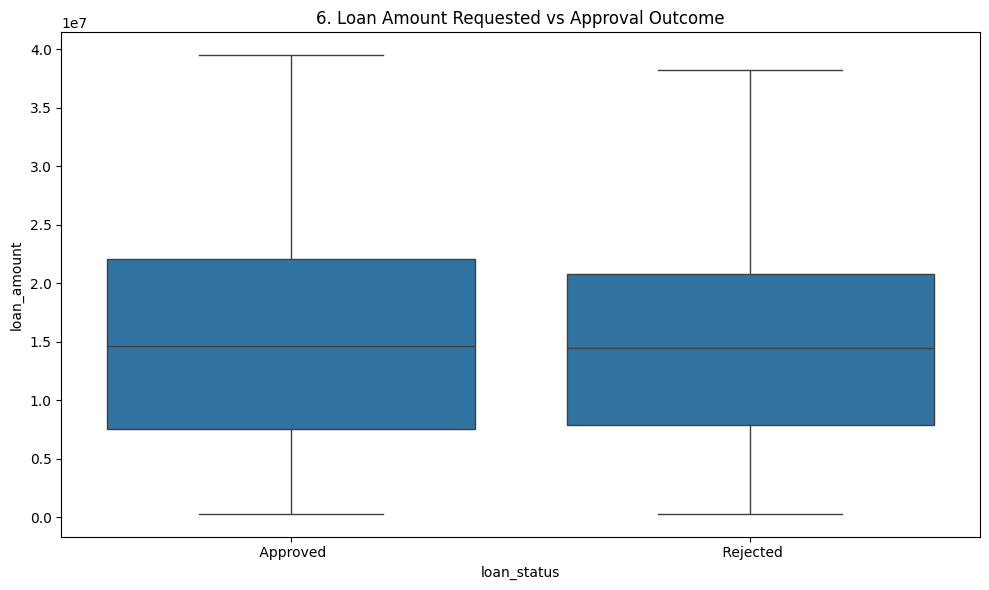

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='loan_status', y='loan_amount', data=df)
plt.title(f'{plot_no}. Loan Amount Requested vs Approval Outcome')
show_fig()
plot_no += 1

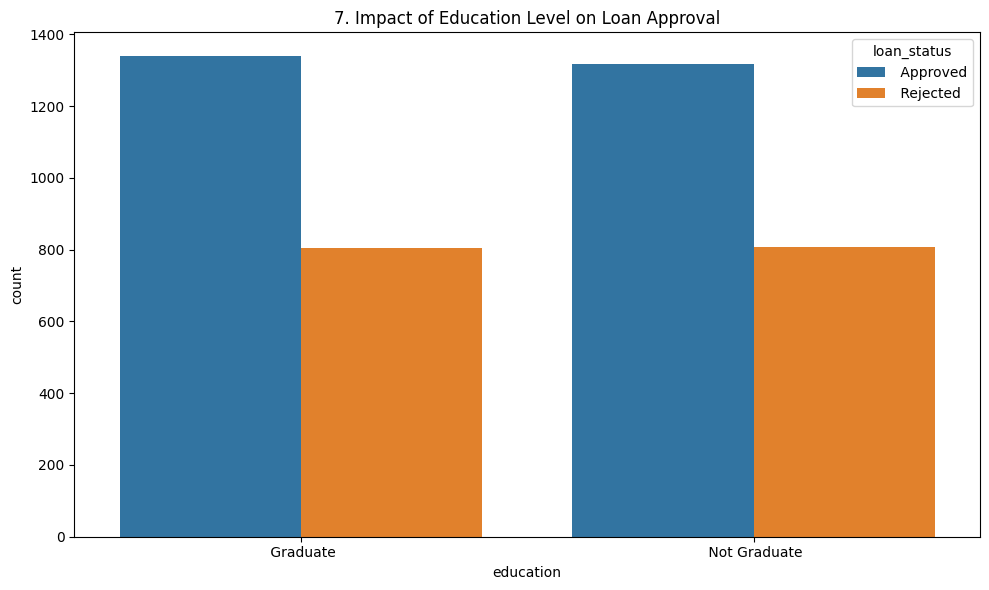

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='education', hue='loan_status', data=df)
plt.title(f'{plot_no}. Impact of Education Level on Loan Approval')
show_fig()
plot_no += 1

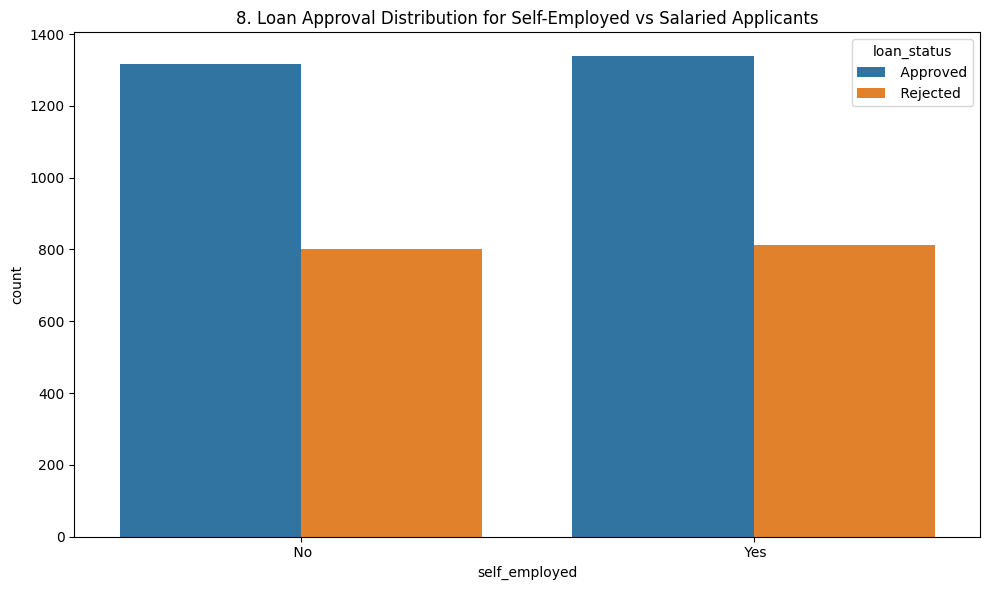

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='self_employed', hue='loan_status', data=df)
plt.title(f'{plot_no}. Loan Approval Distribution for Self-Employed vs Salaried Applicants')
show_fig()
plot_no += 1

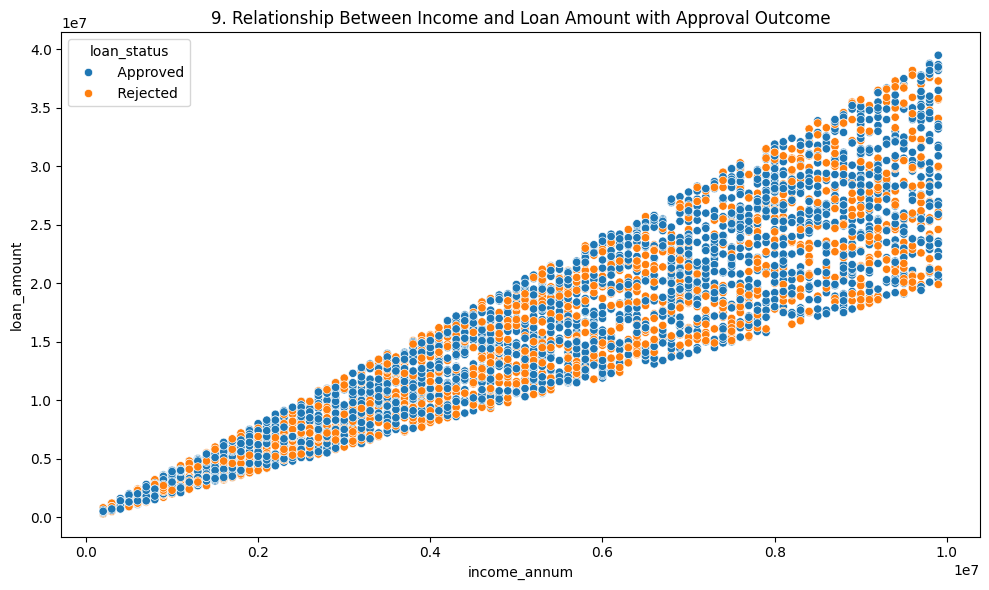

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='income_annum', y='loan_amount', hue='loan_status', data=df)
plt.title(f'{plot_no}. Relationship Between Income and Loan Amount with Approval Outcome')
show_fig()
plot_no += 1

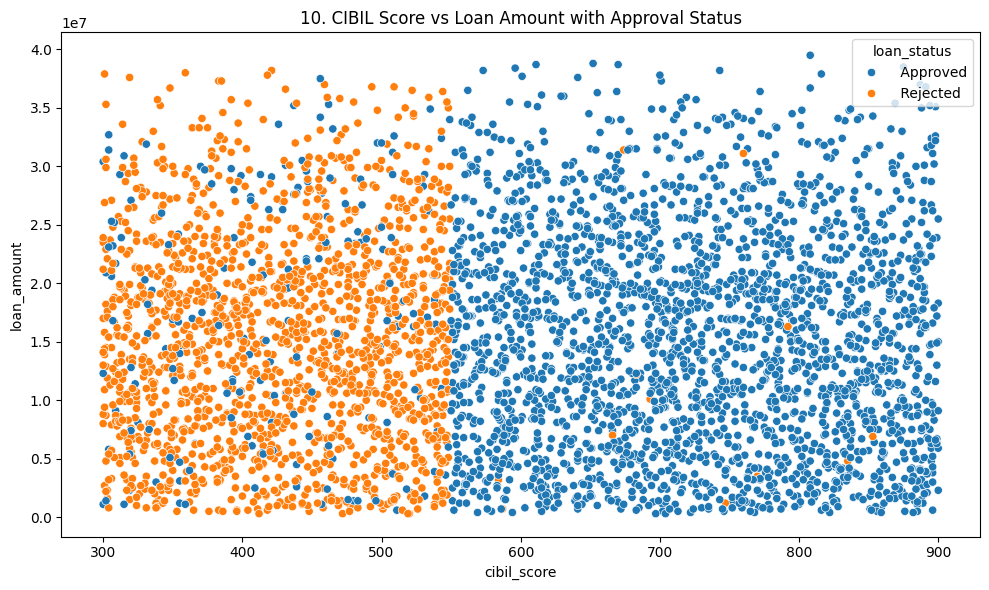

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='cibil_score', y='loan_amount', hue='loan_status', data=df)
plt.title(f'{plot_no}. CIBIL Score vs Loan Amount with Approval Status')
show_fig()
plot_no += 1

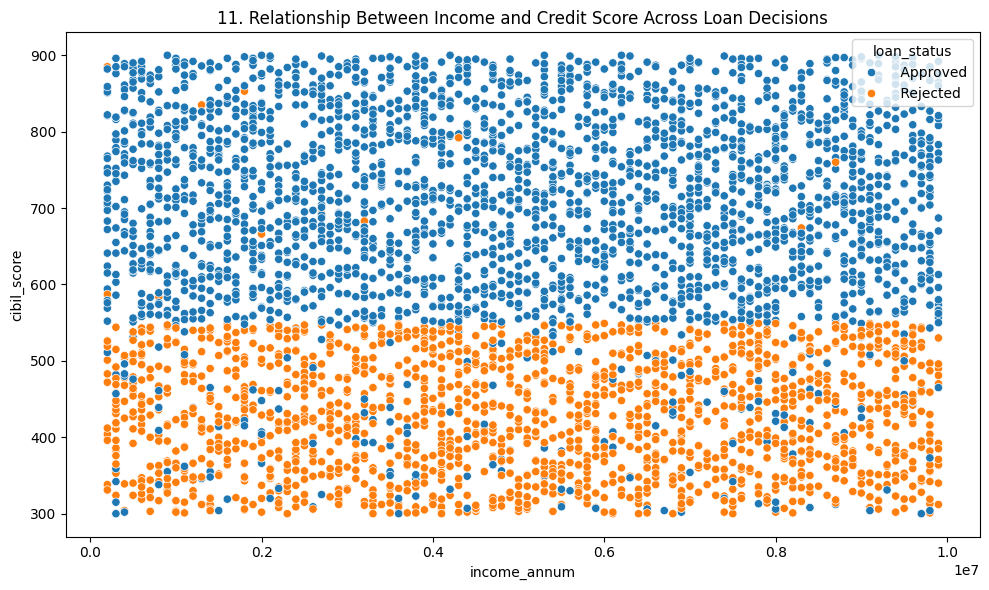

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='income_annum', y='cibil_score', hue='loan_status', data=df)
plt.title(f'{plot_no}. Relationship Between Income and Credit Score Across Loan Decisions')
show_fig()
plot_no += 1

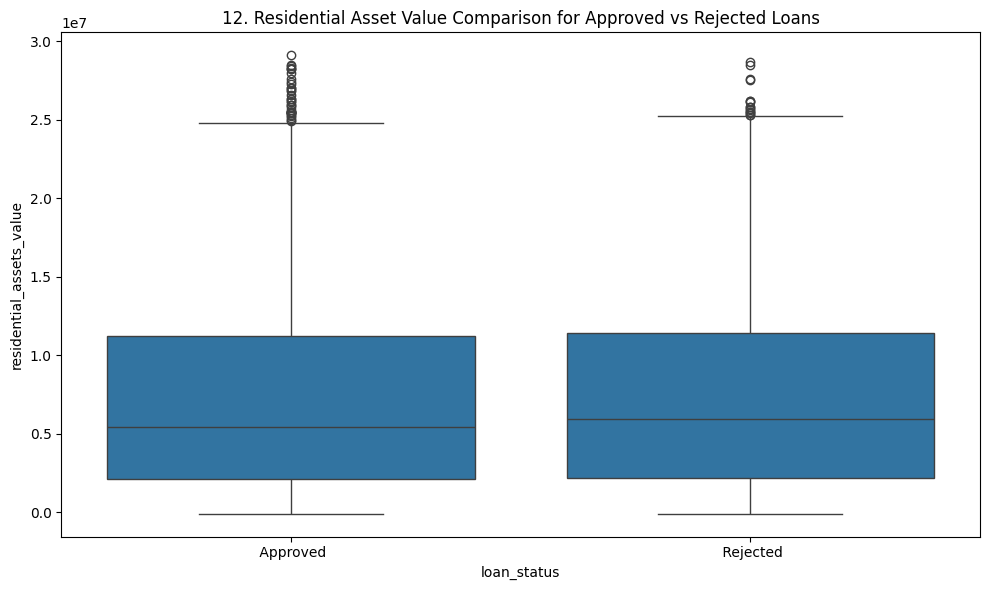

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='loan_status', y='residential_assets_value', data=df)
plt.title(f'{plot_no}. Residential Asset Value Comparison for Approved vs Rejected Loans')
show_fig()
plot_no += 1

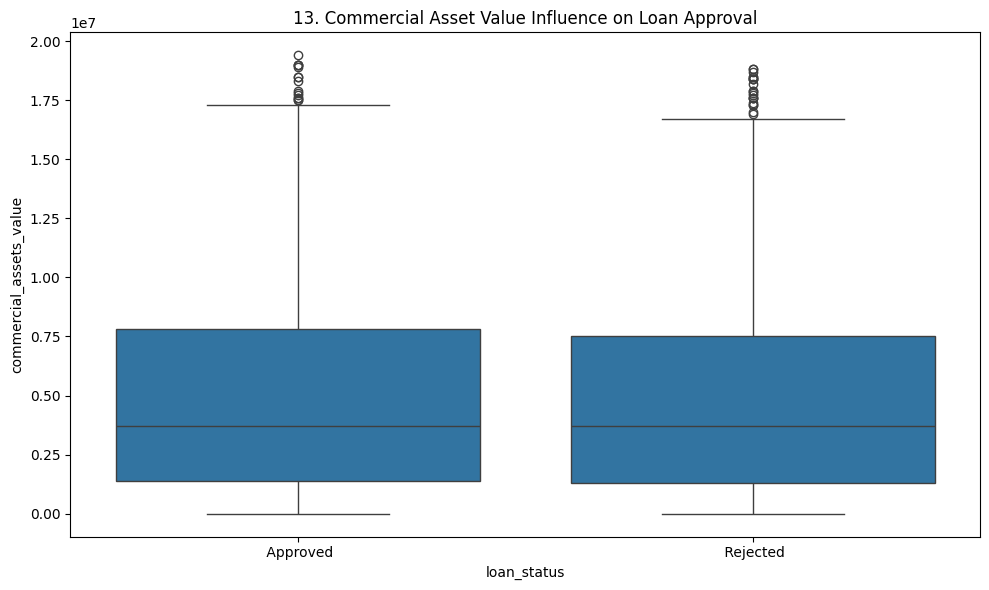

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='loan_status', y='commercial_assets_value', data=df)
plt.title(f'{plot_no}. Commercial Asset Value Influence on Loan Approval')
show_fig()
plot_no += 1

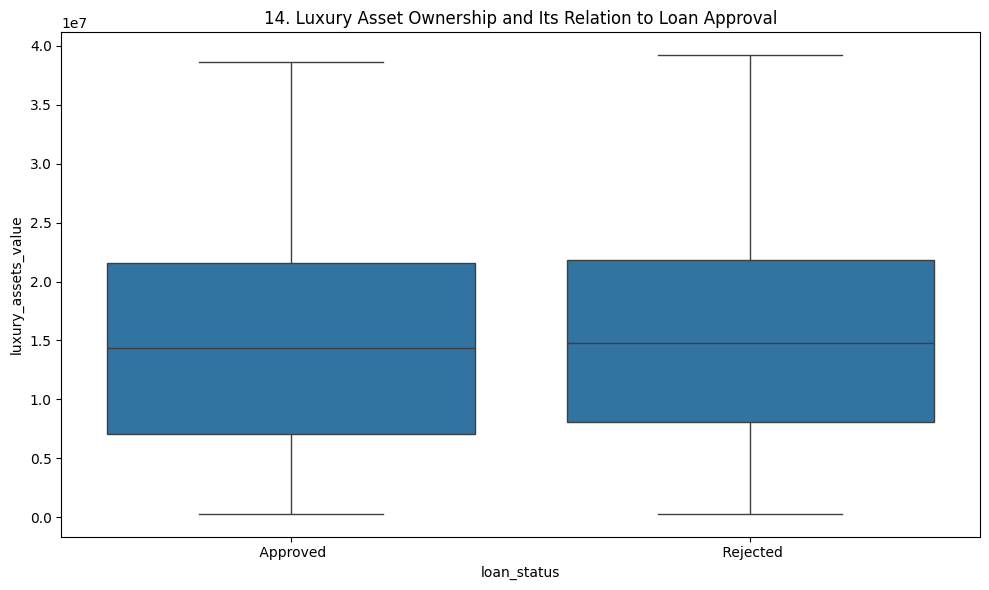

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='loan_status', y='luxury_assets_value', data=df)
plt.title(f'{plot_no}. Luxury Asset Ownership and Its Relation to Loan Approval')
show_fig()
plot_no += 1

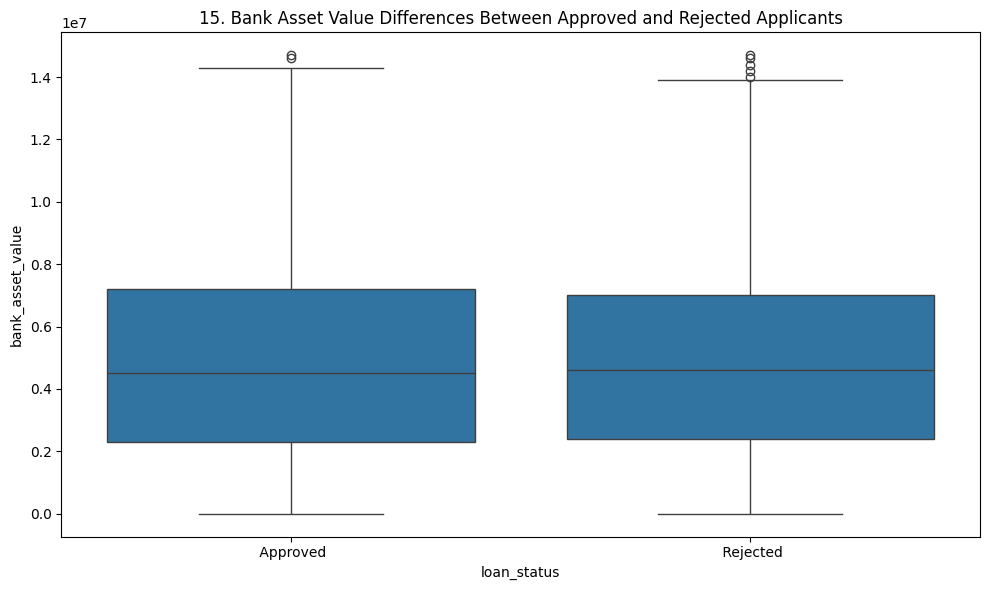

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='loan_status', y='bank_asset_value', data=df)
plt.title(f'{plot_no}. Bank Asset Value Differences Between Approved and Rejected Applicants')
show_fig()
plot_no += 1

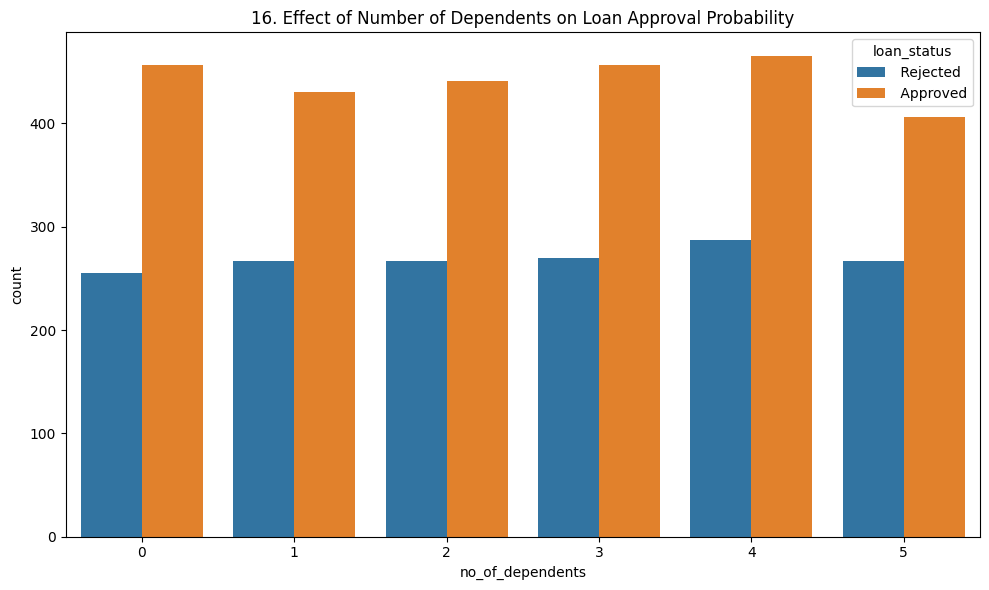

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='no_of_dependents', hue='loan_status', data=df)
plt.title(f'{plot_no}. Effect of Number of Dependents on Loan Approval Probability')
show_fig()
plot_no += 1

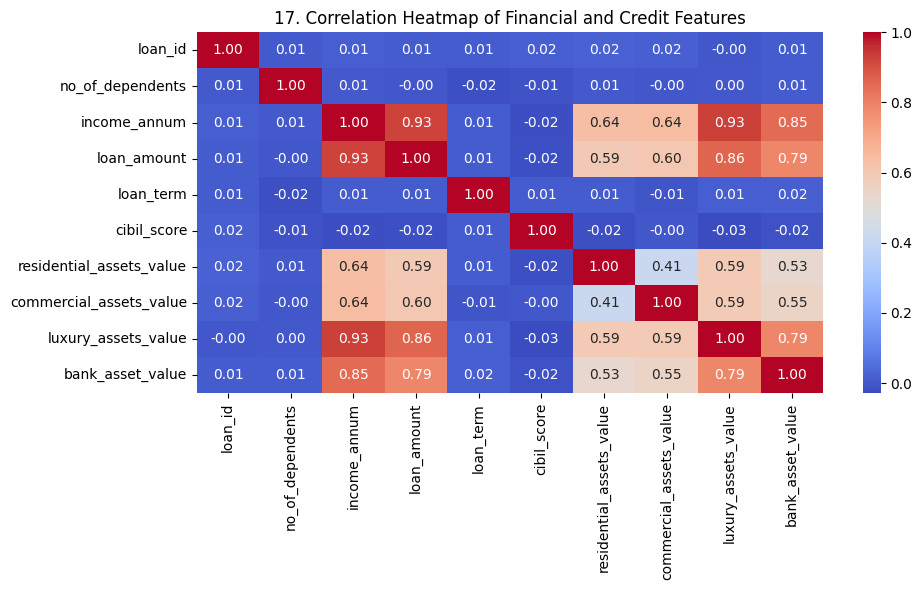

In [29]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f'{plot_no}. Correlation Heatmap of Financial and Credit Features')
show_fig()
plot_no += 1

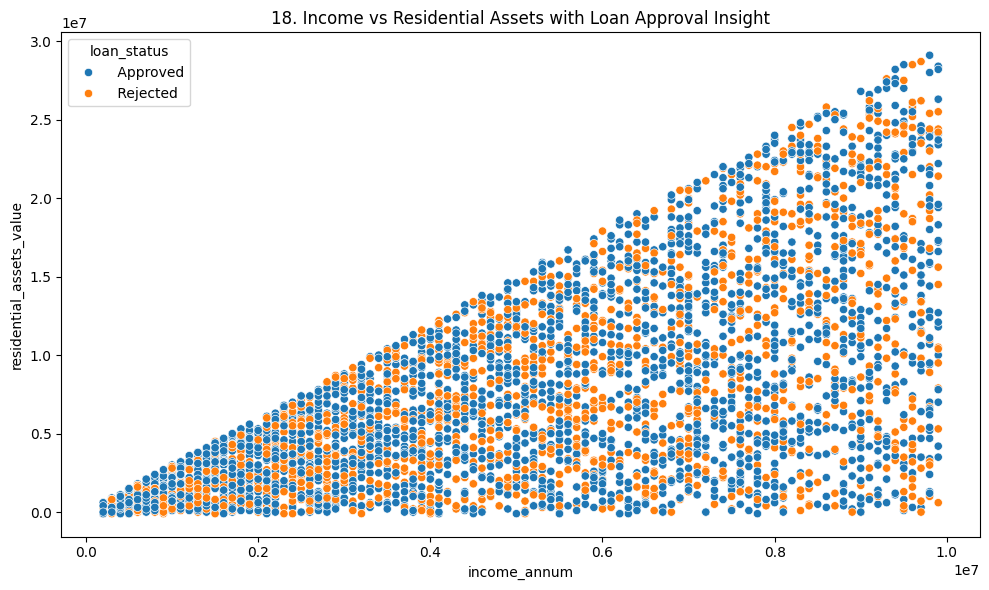

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='income_annum', y='residential_assets_value', hue='loan_status', data=df)
plt.title(f'{plot_no}. Income vs Residential Assets with Loan Approval Insight')
show_fig()
plot_no += 1

# Model Training

## encode categorical columns

In [31]:
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

## split features and target

In [32]:
X = df.drop(['loan_status','loan_id'], axis=1)
y = df['loan_status']

## split dataset into train and test

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale numerical features

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## create and train SVM classifier

In [35]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

SVC()

## make predictions

In [36]:
y_pred = model.predict(X_test)

## calculate accuracy

In [37]:
acc = accuracy_score(y_test, y_pred)
print("Model Accuracy:", acc)

Model Accuracy: 0.9238875878220141


## compute confusion matrix

In [38]:
cm = confusion_matrix(y_test, y_pred)

## plot confusion matrix

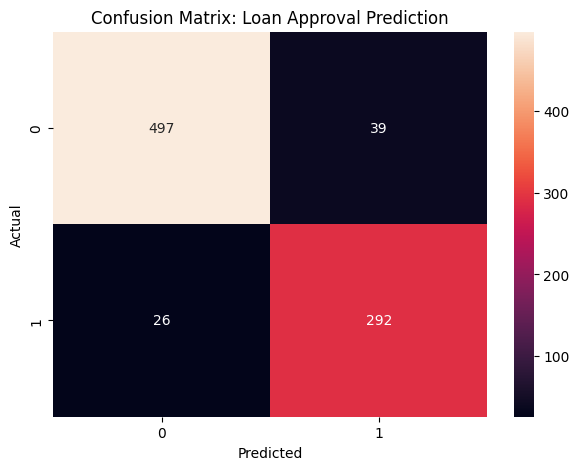

In [39]:
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Loan Approval Prediction")
plt.show()